# Week 4 (follow-up) — Choosing the Decision Threshold

**Problem from `08_bert`:** fine-tuned DistilRoBERTa *ranks* essays almost perfectly (AUC ≈ 1.0), but at the default cut-off of 0.5 it flags too many **human** essays: 1.4% on test and 10.5% of human "Summer projects" essays. For a tool that could accuse a student, a **false positive** (human flagged as AI) is the costly error.

**Fix:** stop using 0.5. 0.5 is only "the middle" if the model's probabilities are well calibrated, and fine-tuned transformers are typically over-confident. Instead, **pick the threshold from the error rate we're willing to accept:**

1. Score the human essays in `val`.
2. Set the threshold so that only **1%** of them land above it (the 99th percentile of human scores). By construction, ~1% of val humans get flagged.
3. Freeze that threshold, then check what happens on `test` and the **held-out slices**: does the 1% false-positive rate hold on unseen topics and generators, and how many AI essays are still caught?

Done for DistilRoBERTa and, for comparison, the TF-IDF + LinearSVM baseline.

In [1]:
import os
import sys
sys.path.append('..')
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_curve

from src.data import load_splits

transformers.logging.set_verbosity_error()
SEED = 42
pd.set_option('display.width', 200)
HUMAN, AI = '#2a78d6', '#eb6834'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.color': '#e6e6e3', 'grid.linewidth': 0.6,
                     'axes.edgecolor': '#9a9a94', 'axes.titleweight': 'bold'})
device = torch.device('cuda')

data = load_splits()
SPLITS = ['val', 'test', 'heldout_prompt', 'heldout_generator']
print(data['split'].value_counts().loc[['train'] + SPLITS])

split
train                28006
val                   3501
test                  3501
heldout_prompt        7135
heldout_generator     2721
Name: count, dtype: int64


## Step 1 — Scores from both models

**DistilRoBERTa:** load the fine-tuned model saved by `08` (no retraining) and score every non-training essay. We keep the **logit**, the raw score before the sigmoid. Many essays score above 0.999 as probabilities, where values squash together, but logits stay spread out (0.999 ≈ logit 6.9, 0.99999 ≈ logit 11.5). Thresholding a logit or its probability gives identical decisions; logits just keep the resolution.

**TF-IDF + LinearSVM:** refit exactly as in `04` (train only, C = 1). Its score is the SVM's signed distance from the boundary.

In [2]:
model_dir = '../models/distilroberta_finetuned'
tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = AutoModelForSequenceClassification.from_pretrained(model_dir).to(device).eval()

scored = data[data['split'].isin(SPLITS)].copy()
ids = tokenizer(scored['text'].tolist(), truncation=True, max_length=512)['input_ids']

def logits_for(ids, batch_size=64):
    out = np.empty(len(ids), dtype=np.float32)
    order = np.argsort([len(x) for x in ids], kind='stable')          # bucket by length, as in 08
    with torch.no_grad(), torch.autocast('cuda', dtype=torch.float16):
        for s in range(0, len(order), batch_size):
            chunk = order[s:s + batch_size]
            width = max(len(ids[i]) for i in chunk)
            x = torch.full((len(chunk), width), tokenizer.pad_token_id, dtype=torch.long)
            for r, i in enumerate(chunk):
                x[r, :len(ids[i])] = torch.tensor(ids[i])
            out[chunk] = model(input_ids=x.to(device), attention_mask=(x != tokenizer.pad_token_id).long().to(device)).logits.squeeze(1).float().cpu().numpy()
    return out

t0 = time.time()
scored['roberta'] = logits_for(ids)
print(f"DistilRoBERTa: scored {len(scored):,} essays in {time.time() - t0:.0f}s")

t0 = time.time()
train = data[data['split'] == 'train']
vec = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=200_000, sublinear_tf=True).fit(train['text'])
svm = LinearSVC(C=1).fit(vec.transform(train['text']), train['label'])
scored['tfidf'] = svm.decision_function(vec.transform(scored['text']))
print(f"TF-IDF + LinearSVM: refit and scored in {time.time() - t0:.0f}s")

# sanity check: the default thresholds reproduce 08's / 04's flag rates on test
t = scored[scored['split'] == 'test']
print(f"\ntest humans flagged at the default thresholds: DistilRoBERTa {(t.loc[t['label'] == 0, 'roberta'] >= 0).mean() * 100:.1f}%"
      f" (08 reported 1.4% of Persuade) | TF-IDF {(t.loc[t['label'] == 0, 'tfidf'] >= 0).mean() * 100:.1f}%")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

DistilRoBERTa: scored 16,858 essays in 70s


TF-IDF + LinearSVM: refit and scored in 50s

test humans flagged at the default thresholds: DistilRoBERTa 1.4% (08 reported 1.4% of Persuade) | TF-IDF 0.0%


(Logit 0 = probability 0.5, so "≥ 0" is the old default for both models.)

## Step 2 — The trade-off on `val`

Every threshold gives one **false-positive rate** (share of humans flagged) and one **detection rate** (share of AI caught). Lowering the false-positive rate means raising the threshold, which eventually costs detections. The curve below is the ROC curve with a log-scaled x-axis, because the region that matters (FPR below a few %) is squeezed into the corner on a normal ROC plot.

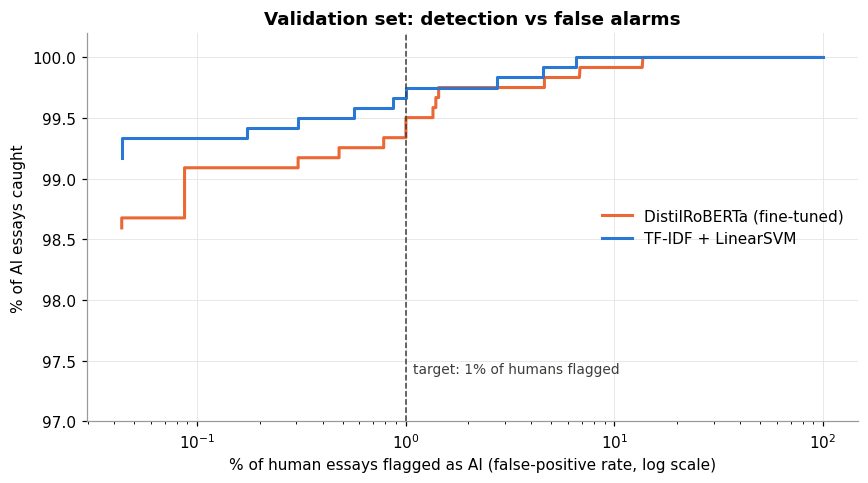

In [3]:
val = scored[scored['split'] == 'val']
fig, ax = plt.subplots(figsize=(8, 4.5))
for col, color, name in [('roberta', AI, 'DistilRoBERTa (fine-tuned)'), ('tfidf', HUMAN, 'TF-IDF + LinearSVM')]:
    fpr, tpr, _ = roc_curve(val['label'], val[col])
    keep = fpr > 0
    ax.plot(fpr[keep] * 100, tpr[keep] * 100, color=color, linewidth=2, label=name)
ax.axvline(1, color='#3d3d3a', linewidth=1, linestyle='--')
ax.annotate('target: 1% of humans flagged', (1, 97.4), xytext=(5, 0), textcoords='offset points', fontsize=9, color='#3d3d3a')
ax.set_xscale('log')
ax.set_xlabel('% of human essays flagged as AI (false-positive rate, log scale)')
ax.set_ylabel('% of AI essays caught')
ax.set_ylim(97, 100.2)
ax.set_title('Validation set: detection vs false alarms', fontsize=12)
ax.legend(frameon=False, loc='center right')
fig.tight_layout()
fig.savefig('../images/09_val_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 3 — Pick the thresholds on `val`

For each target false-positive rate, the threshold is the matching **quantile of human val scores**: for 1%, the 99th percentile. A higher target (5%) is more lenient; a lower one (0.5%) is stricter. With 2,291 val humans, 1% means ~23 essays above the line, enough for a stable estimate. Below ~0.5% the estimate rests on a handful of essays, so we stop there.

In [4]:
targets = [0.05, 0.01, 0.005]
val_h = val[val['label'] == 0]
thresholds = pd.DataFrame({col: {t: float(np.quantile(val_h[col], 1 - t)) for t in targets} for col in ['roberta', 'tfidf']})
thresholds.index.name = 'target FPR'
thresholds.loc['default'] = 0.0
thresholds.round(3)

,roberta,tfidf
target FPR,,
0.05,-6.256,-0.747
0.01,4.666,-0.508
0.005,7.796,-0.388
default,0.000,0.000


For DistilRoBERTa the 1% threshold is a logit far above 0, i.e. a probability very close to 1. That's the over-confidence: a "0.5" from this model isn't a 50/50 call.

## Step 4 — Apply the frozen thresholds everywhere

For each model and threshold, report per set:
- **% humans flagged** (false-positive rate): should stay near the target if the threshold transfers;
- **% AI caught** (detection rate);
- **precision**: of the flagged essays, the share that are really AI.

On-topic essays only, as in `06`–`08`. (The held-out-generator slice has no humans, so it only gets a detection rate.)

In [5]:
def rates(d, col, thr):
    flagged = d[col] >= thr
    h, a = d['label'] == 0, d['label'] == 1
    return {'% humans flagged': flagged[h].mean() * 100 if h.any() else np.nan,
            '% AI caught': flagged[a].mean() * 100,
            'precision': (flagged & a).sum() / max(flagged.sum(), 1)}

on = scored[scored['on_topic']]
rows = []
for col, model_name in [('roberta', 'DistilRoBERTa'), ('tfidf', 'TF-IDF + SVM')]:
    for target in ['default'] + targets:
        thr = thresholds.loc[target, col]
        for split in SPLITS:
            rows.append({'model': model_name, 'threshold': target if target == 'default' else f'FPR {target:.1%}',
                         'set': split, **rates(on[on['split'] == split], col, thr)})
table = pd.DataFrame(rows).set_index(['model', 'threshold', 'set']).unstack('set')
table = table.reindex(columns=SPLITS, level=1).round(2)
table[['% humans flagged', '% AI caught']]

% humans flagged                                        % AI caught                                        
set                                  val  test heldout_prompt heldout_generator         val   test heldout_prompt heldout_generator
model         threshold                                                                                                            
DistilRoBERTa FPR 0.5%              0.53  0.40           2.31               NaN       98.92  99.37         100.00             99.17
              FPR 1.0%              1.01  0.92           3.85               NaN       99.14  99.58         100.00             99.76
              FPR 5.0%              4.93  3.79          12.49               NaN       99.78  99.79         100.00             99.95
              default               1.98  1.36           5.61               NaN       99.57  99.58         100.00             99.90
TF-IDF + SVM  FPR 0.5%              0.48  0.53          20.75               NaN       99.35  99.58         100.00             98.68
              FPR 1.0%              0.88  1.23          33.80               NaN       99.57  99.58         100.00             99.37
              FPR 5.0%              4.67  6.25          64.46               NaN       99.78  99.79         100.00             99.95
              default               0.00  0.00           2.10               NaN       98.27  98.73          97.63             87.99

How to read it, per row: `val` humans flagged should equal the target by construction. Then look along the row. **Does the false-positive rate stay close on `test`** (same distribution) and **on `heldout_prompt`** (new topics)? And how much detection is lost on `heldout_generator`?

In [6]:
print("Held-out prompts, by prompt, at the 1% threshold (on-topic essays):")
ho = on[on['split'] == 'heldout_prompt']
out = []
for col, model_name in [('roberta', 'DistilRoBERTa'), ('tfidf', 'TF-IDF + SVM')]:
    for p, d in ho.groupby('prompt_name'):
        out.append({'model': model_name, 'prompt': p,
                    **rates(d, col, thresholds.loc[0.01, col]),
                    '% humans flagged @default': rates(d, col, 0.0)['% humans flagged']})
pd.DataFrame(out).set_index(['model', 'prompt']).round(2)

Held-out prompts, by prompt, at the 1% threshold (on-topic essays):


% humans flagged  % AI caught  precision  % humans flagged @default
model         prompt                                                                                               
DistilRoBERTa Does the electoral college work?              1.31        100.0       0.98                       2.43
              Summer projects                               7.73        100.0       0.67                      10.48
TF-IDF + SVM  Does the electoral college work?             32.09        100.0       0.67                       0.90
              Summer projects                              36.43        100.0       0.30                       3.95

## Step 5 — Who is still flagged at the strict threshold?

Read the human essays that DistilRoBERTa still flags at its 1% threshold on test and on the held-out prompts. These are the hardest cases: what kind of human writing looks "AI" to the model?

In [7]:
thr = thresholds.loc[0.01, 'roberta']
fp = on[(on['label'] == 0) & (on['roberta'] >= thr) & on['split'].isin(['test', 'heldout_prompt'])]
print(f"{len(fp)} human essays flagged at the 1% threshold (test + held-out prompts, on-topic)\n")
print("their length vs all on-topic humans in those sets (words):",
      f"median {fp['n_words'].median():.0f} vs {on[(on['label'] == 0) & on['split'].isin(['test', 'heldout_prompt'])]['n_words'].median():.0f}\n")
for _, r in fp.sample(min(4, len(fp)), random_state=SEED).iterrows():
    print(f"[logit {r['roberta']:.1f} | {r['split']} | {r['prompt_name']} | {r['n_words']} words]")
    print(r['text'][:380].replace('\n', ' '), '...\n')

191 human essays flagged at the 1% threshold (test + held-out prompts, on-topic)

their length vs all on-topic humans in those sets (words): median 489 vs 442

[logit 9.6 | heldout_prompt | Does the electoral college work? | 226 words]
Dear Senator,  In the year 2000, a great injustice was made in our country.  The president who the people voted for was unfairly defeated because of the electoral college.  Our government says that it is by the people and for the people, but the electoral college is against this whole ideal.  The electoral college is unfair, undemocratic, and outdated.  To begin with, the elect ...

[logit 6.2 | heldout_prompt | Summer projects | 886 words]
Preparedness is a quality attributed to future success. This is why schools across the country have students complete summer assignments, as they wish to prepare those students for the rigors of high-level courses. Yet, despite the good intentions, many students often complain of these summer assignments being tedious

## Step 6 — Save the thresholds

The demo (Week 8) and later notebooks should use these thresholds, not 0.5. Save the thresholds and the summary table.

In [8]:
thresholds.to_csv('../results/09_thresholds.csv')
table.to_csv('../results/09_threshold_rates.csv')
print(open('../results/09_thresholds.csv').read())

target FPR,roberta,tfidf
0.05,-6.255859375,-0.7471501212054311
0.01,4.666048049926758,-0.5084273702693006
0.005,7.796499252319336,-0.3875199582204116
default,0.0,0.0



## Key takeaways

- **For DistilRoBERTa, choosing the threshold on `val` works in-distribution:** at the 1%-FPR threshold (logit 4.67, i.e. probability ≈ 0.991), test humans flagged fall from 1.36% to **0.92%**, while still catching 99.6% of test AI and **99.8% of the unseen generators**. A "0.5" from this model is not a 50/50 call; it's over-confident.
- **In-distribution, TF-IDF is actually the better detector:** on the val curve it catches slightly more AI than DistilRoBERTa at *every* false-positive rate (at the 1% threshold: 99.6% vs 99.1% of val AI essays caught). The transformer's advantage appears only under shift: unseen generators (99.8% vs 88% at default thresholds) and the behaviour of its threshold on new topics (next point). Picking the "best model" on `test` alone would have chosen TF-IDF.
- **On unseen topics, a threshold set on val only partly holds.** Held-out-prompt humans flagged: 5.6% (default) → **3.9%** (1% target) → **2.3%** (0.5% target), against ~1% intended. "Summer projects" humans are still flagged 7.7% of the time at the 1% threshold. **No threshold fixed in advance guarantees the false-positive rate on a new topic.** That's a limitation to state plainly in the report and the demo.
- **For TF-IDF, val calibration makes things worse.** Its default threshold already flags 0% of val humans, so "calibrating to 1%" *lowers* it, and on the held-out prompts the share of humans flagged jumps from **2.1% to 33.8%**. TF-IDF's scores for humans shift heavily on unseen topics; its default threshold only worked because it happened to sit far on the safe side. Lesson: calibrate on data that resembles deployment, and always check the shifted slices.
- **Best operating point found: DistilRoBERTa at the 0.5% target (logit 7.80).** 0.40% of test humans and 2.3% of held-out-prompt humans flagged (about TF-IDF's default 2.1%), while detecting **99.2% of unseen-generator essays vs TF-IDF's 88.0%**. Caveat: the 0.5% quantile rests on ~12 val essays, so the threshold itself is noisy.
- **Who still gets flagged:** human essays above the strict threshold are *longer* than average (median 489 vs 442 words) and polished: formal letters ("Dear Senator, …"), clear structure, few errors. **The detector's residual false positives fall on the strongest student writers**, the central fairness point for the ethics section.
- Thresholds are saved in `results/09_thresholds.csv` (logit scale for DistilRoBERTa; SVM decision value for TF-IDF). Later notebooks and the demo should use them instead of 0.5.
